# Quantum PCA for Financial Dataset
### **Learning Objectives**
1. Why use Principal Component Analysis (PCA)? How to use PCA?
2. Apply PCA to a dataset. Form statistical conclusions per results.
3. Understand and mitigate the impact of outliers and noisy data.
3. Why use Quantum Annealing (QA)? How to use QA?
4. Experiment with implementing a QA algorithm.

#### **Principal Component Analysis**
*Principal Component Analysis* (PCA) is a common data science procedure used for extracting key features (aka principal components) from a dataset. Knowing the principal components is helpful for dimensionality reduction, denoising, and visualization.  
For an intuitive understanding of PCA, here is a [great rundown from IBM](https://www.ibm.com/think/topics/principal-component-analysis) and youtube has a plethora of instructive videos. Develop an understanding of the fundamentals before continuing.  
Understand both the recursive formulation of PCA and the implementation that solves for several principal components simultaneously.  

### **Quantum Annealing**
*Quantum Annealing* (QA) is an optimization algorithm for finding the global minimum of a solution set. It works by creating quantum fluctations in input data to explore the dataset.  
For an intuitive understanding of QA, there are also some youtube videos that have great visualizers. Here is a [great video](https://youtu.be/zvfkXjzzYOo?si=t1X2Nl-277pAQDV4) from D-Wave.

### **QaPCA**
*Quantum Annealing for Robust Principal Component Analysis* ([pdf](https://arxiv.org/pdf/2501.10431)), published in December 2024, introduced an implementation of PCA using Quantum Annealing. The goal of the article was to develop a *robust* implementation, i.e. an implementation that mitigated the impact of noise.  

### **Problem Statement - Detecting and Analyzing Financial Principal Components with QAPCA**
This challenge will have competitors build L1-PCA classically, followed by QAPCA-R, in order to visualize the natural groupings of different tickers into sectors from price movements. Competitors will be tested on how robustly their implementation manages noise from both the quantum system and the data itself.
##### Input: Time series of stock prices
Steps:
1. Pre-process data
2. Apply PCA classically. 
3. Analyze results.
4. Construct Ising Model for Recursive QaPCA.
5. Analyze results. How do they compare with classical PCA?
6. Bonus.

## Step 0: Downloading data
We will be utilizing stock price data from 2018/01/01 to 2018/03/01 for various different tickers from different sectors. The list of tickers and their corresponding sector are listed as follows:
| Ticker | Company Name           | Sector         |
|--------|------------------------|----------------|
| AAPL   | Apple Inc.             | Technology     |
| AMZN   | Amazon.com Inc.        | Technology     |
| GOOG   | Alphabet Inc Class C   | Technology     |
| MSFT   | Microsoft Corporation  | Technology     |
| XOM    | Exxon Mobil Corp       | Energy         |
| GLD    | SPDR Gold Trust        | Finance        |
| AEP    | Amer. Elec. Power Comp | Utility        |
| DUK    | Duke Energy Corp       | Utility        |
| SO     | Southern Co            | Utility        |

In [ ]:
# Handle imports
import pandas as pd
import yfinance as yf
import numpy as np
import os
import math
import random
import neal
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from midiutil import MIDIFile
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
import plotly.express as px
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from scipy.optimize import minimize
import os



from scipy.optimize import dual_annealing

In [5]:
tickers_path = 'data/prices.csv'

if os.path.exists(tickers_path):
    ticker_data = pd.read_csv(tickers_path)
else:
    tickers = ['GOOG', 'XOM', 'AAPL', 'AMZN', 'GLD', 'DUK', 'SO', 'AEP']
    date_range = ['2017-01-01', '2017-03-01']

    ticker_data = yf.download(
        tickers,
        start=date_range[0],
        end=date_range[1],
        group_by="ticker",
        auto_adjust=True
    )
    ticker_data = ticker_data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()

    ticker_data.to_csv(tickers_path, index=False)

## Step 1: Preparing data
For each ticker, we will look at their daily log returns over the period 2018/01/01 to 2018/03/01. We will treat this list of returns as each ticker's "feature", which acts as a descriptor for the ticker. Compute the daily difference between log returns for each ticker over the provided time period.

In [ ]:
#moving data so we have index and ticker columns with adjusted prices cause PCA needs a matrix
price_df = ticker_data.pivot(index="Date", columns="Ticker", values="Close")

#log returns
log_returns = np.log(price_df / price_df.shift(1)).dropna()

data = log_returns

#preview data
print("Log returns shape:", log_returns.shape)
print("Nameless log returns shape:", data)
data.head()

Log returns shape: (38, 8)
Nameless log returns shape: Ticker          AAPL       AEP      AMZN       DUK       GLD      GOOG  \
Date                                                                     
2017-01-04 -0.001120  0.001433  0.004646 -0.001030  0.003524  0.000966   
2017-01-05  0.005073  0.005395  0.030270  0.001287  0.015396  0.009007   
2017-01-06  0.011087 -0.000792  0.019716 -0.003350 -0.007400  0.015161   
2017-01-09  0.009118 -0.013232  0.001168 -0.011030  0.008199  0.000620   
2017-01-10  0.001008 -0.003054 -0.001281 -0.001829  0.004251 -0.002309   
2017-01-11  0.005359  0.016920  0.003912  0.007813  0.003088  0.003869   
2017-01-12 -0.004184  0.001740  0.018132  0.005691  0.003606 -0.001920   
2017-01-13 -0.001763 -0.000948  0.004292 -0.004265  0.002630  0.001883   
2017-01-17  0.008032  0.009131 -0.009122  0.003233  0.014257 -0.004056   
2017-01-18 -0.000084 -0.005500 -0.002770  0.000516 -0.008495  0.001813   
2017-01-19 -0.001752 -0.012048  0.001930 -0.004915 -0.000

Ticker,AAPL,AEP,AMZN,DUK,GLD,GOOG,SO,XOM
Date,,,,,,,,
2017-01-04,-0.001120,0.001433,0.004646,-0.001030,0.003524,0.000966,-0.001020,-0.011063
2017-01-05,0.005073,0.005395,0.030270,0.001287,0.015396,0.009007,0.003057,-0.015019
2017-01-06,0.011087,-0.000792,0.019716,-0.003350,-0.007400,0.015161,-0.002649,-0.000565
2017-01-09,0.009118,-0.013232,0.001168,-0.011030,0.008199,0.000620,-0.009842,-0.016635
2017-01-10,0.001008,-0.003054,-0.001281,-0.001829,0.004251,-0.002309,-0.003096,-0.012835


## Step 2: Apply PCA classically
We will now apply PCA classically on our set of features. Per section 2.2 from the QAPCA paper (linked above), L1-PCA can be defined as the following problem:
$$
    \mathbf{\hat{R}}_{L_1} = \underset{\mathbf{R} \in \mathbb{R}^{D \times K}, \mathbf{R}^T\mathbf{R=I}_K}{\operatorname{\argmax}} ||\mathbf{R}^T\mathbf{X}||_1
$$
where $||*||_1$ is the L1-norm of a vector (sum of absolute entries).  
The paper walks through how to transform this into the binary optimization problem
$$
\mathbf{\hat{R}}_{L_1} = \Phi\left(\mathbf{X}\mathbf{B_{opt}} \right)
$$
where
$$
\mathbf{B_{opt}} = \underset{\mathbf{B} \in \{\pm 1\}^{N \times K}}{\operatorname{\argmax}}\sum_{k=1}^K {\sigma}_k \left[\mathbf{B}^T \mathbf{X}^T \mathbf{XB} \right]
$$
Per the paper, $K$ is the number of PCA components, ${\sigma}_k[*]$ represents the $k^{th}$ singular-value of its argument (derived from SVD), $\mathbf{B} \in \{ \pm 1\}^{N \times K}$ is a binary matrix, and $\Phi(*)$ returns the nearest orthonormal matrix to its argument (solved using SVD).  
For $K = 1$, this expression becomes
$$
\mathbf{B_{opt}} = \underset{\mathbf{B} \in \{\pm 1\}^N}{\operatorname{\argmax}} ||\mathbf{X} \hat{\mathbf{b}}||_2 = \underset{\mathbf{B} \in \{\pm 1\}^N}{\operatorname{\argmax}} \: \hat{\mathbf{b}}^T \mathbf{X}^T\mathbf{X} \hat{\mathbf{b}} 
$$
This binary quadratic form is formally an [NP-hard problem](https://arxiv.org/abs/2301.06978)!!! These are magic words for quantum nerds. We can then rewrite this formulation in Ising form as:
$$
\mathbf{b_{opt}} = \underset{\hat{\mathbf{b}}\in\{\pm 1\}^N}{\operatorname{\argmin}} \hspace{2mm} \hat{\mathbf{b}}^T\left( - \mathbf{X}^T\mathbf{X} \right)\hat{\mathbf{b}} = \underset{\hat{\mathbf{b}}\in\{\pm 1\}^N}{\operatorname{\argmin}} \hspace{2mm} \hat{\mathbf{b}}^T(-\mathbf{J})\hat{\mathbf{b}}
$$
where $J$ represents the covariance matrix.  

We can iteratively anneal and update the covariance matrix to solve for one principal component at a time.  
We offer functions and descriptions, as well as the steps for calling. We recommend implementing helper functions yourself instead of using packages. At one step you should use some optimizer package, e.g. dual_annealing from scipy.optimize.

In [ ]:
#Manual Custom Simulated Annealer for L1-PCA
"aims to find optimal +_ patterns to maximize stock covariance by using temperature-based random search and iteratively flipping through bits and accepting solutions based on cooling schedule"
"Returns binary vectors representing stock groupings for robust PCA"

class L1PCAResults:
   'creates container for L1-PCA Method'
   def __init__(self, method_name):
        self.method_name = method_name
        self.b_vectors = None
        self.pca_components = None
        self.best_energy = None
        self.energy_values = []
        self.X = None
        self.J = None
        self.individual_results = []



def solve_covariance_matrix(data):
    "Calculate covariance matrix for given sample data"
    J = np.cov(data, rowvar=False)
    return J

def l1_objective(b, J):
    """
    Compute the L1 PCA objective function.

    Parameters:
    -----------
    b : numpy.ndarray
        The current component vector (will be reshaped to column vector)
    J : numpy.ndarray
        The covariance matrix or modified covariance matrix for the optimization
        
    Returns:
    --------
    float
        The l1 objective function value
    """
    
    b = b.reshape(-1,1)     #converts b to column vector
    temp = J @ b
    B = b.T @ temp         

    return -float(B[0,0]) 


"""
Parameters: 

Imported transpose (J) 

Number of iterations 

K: number of principal components (presumed 1)

N: number of assets 
"""
def manual_anneal(J, max_iterations=10000): #10000 iterations to try to get best results
    'goal is to do simulated annealing to find optimal binary matrix for L1-PCA,returns a result container'
    'Returns a results container with the solution.'

    N = J.shape[0]
    results = L1PCAResults("Manual Annealing - Single Component")
    results.J = J
    
    #create a random binary matrix that can normalize the vector and create the best matrix
    matrix_B = np.random.choice([-1, 1], N)
    best_matrix = matrix_B.copy()
    best_value = l1_objective(best_matrix, J)
    
    #annealing loop
    for i in range(max_iterations):
        #iterates by flipping bits and computes objective values than updates until current solution is accepted for exploration and store
        matrix_new = iterate(matrix_B)
        value_new = l1_objective(matrix_new, J)
        if value_new < best_value:
            best_matrix = matrix_new.copy()
            best_value = value_new
        value_current = l1_objective(matrix_B, J)
        if compare_values(value_new, value_current, i, max_iterations):
            matrix_B = matrix_new
    
    results.b_vectors = best_matrix
    results.best_energy = best_value
    
    return results


    
def iterate(matrix_to_iterate):
    'Propose a new solution by flipping one random entry. Basically using "neighbour" function. Select random position and flip the sign'
    matrix_new = matrix_to_iterate.copy()
    i = np.random.randint(0, matrix_new.shape[0])
    matrix_new[i] *= -1
    
    return matrix_new


def compare_values(value_new, value_old, i, max_iterations):
    """Acceptance criterion for simulated annealing (maximization version).
    Uses pre-computed objective values to avoid redundant evaluations.
    
    Always accepts improvements.
    Accepts worse solutions with probability exp(delta/T) where delta < 0.
    Probability decreases as temperature T decreases over iterations.
    """
    #comparing old and new solution + accepts worse solution with probability exp(delta/T)
    if value_new > value_old:
        return True
    delta = value_new - value_old  
    probability = math.exp(delta / temp_function(i, max_iterations))     #as temperature decreases, this probability approaches 0
    return random.random() < probability #random acceptance based on probability

    
def temp_function(i, max_iterations):
    """
    Temperature schedule: exponentially decreases from T_0 to T_final.
    
    High temperature early → willing to accept bad moves (exploration)
    Low temperature late → only accept improvements (exploitation)
    """
    T_0 = 100   
    T_final = 0.01
    return T_0 * ((T_final / T_0) ** (i / max_iterations)) #cooling schedule

#Phi function (r)
def phi(T):
    U, _, Vt = np.linalg.svd(T, full_matrices=False)
    return U 

def find_k_b_vectors(k, data):
    X = data.values.T 
    components = []
    X_remaining = X.copy()
    
    for i in range(k):
        J = X_remaining @ X_remaining.T
        b_i = manual_anneal(J, max_iterations=10000)
        components.append(b_i)
        b_i = b_i.reshape(-1, 1)
        X_remaining = X_remaining - (b_i @ b_i.T @ X_remaining)
    
    return np.array(components)
    


In [ ]:
#DUAL ANNEALING

def solve_l1_classical_component(J, X_data, max_iterations=10000):
    """
    Solve for a single L1 PCA component using scipy's dual_annealing.
    Returns a results container with the solution.
    
    Parameters:
    -----------
    J : numpy.ndarray
        The covariance matrix (stocks × stocks)
    X_data : numpy.ndarray
        The original data matrix (stocks × days)
        
    Returns:
    --------
    L1PCAResults
        Container with the component solution
    """
    n_stocks = J.shape[0]
    bounds = [(-1, 1) for _ in range(n_stocks)]
    
    results = L1PCAResults("Dual Annealing - Single Component")
    results.J = J
    
    #ptimization
    result = dual_annealing(
        lambda x: l1_objective(np.sign(x), J),
        bounds,
        maxiter=max_iterations,
        seed=123
    )
    
    B = np.sign(result.x)
    B = np.where(B == 0, 1, B)
    
    results.b_vectors = B
    results.best_energy = -result.fun  #dual_annealing minimizes, so negate to get max
    
    return results

In [ ]:
# Quantum Annealing
def convert_J_to_ising_model(J):
    """
    Converts covariance matrix J into dict of Ising Model couplings.
    """
    N = J.shape[0]
    coupl_dict = {}
    for x in range(N):
        for y in range(x+1, N):
            coupl_dict[(x,y)] = -0.5 * J[x,y]
    return coupl_dict


def solve_l1_quantum_component(J, X_data, max_iterations=10000):
    """
    Solve for a single L1 PCA component using quantum annealing (D-Wave neal).
    Returns a results container with the solution.
    
    Parameters:
    -----------
    J : numpy.ndarray
        The covariance matrix (stocks × stocks)
    X_data : numpy.ndarray
        The original data matrix (stocks × days)
        
    Returns:
    --------
    L1PCAResults
        Container with the component solution
    """
    results = L1PCAResults("Quantum Annealing - Single Component")
    results.J = J
    
    coup = convert_J_to_ising_model(J)
    h = {}
    
    #run quantum annealing with neal
    sampler = neal.SimulatedAnnealingSampler()
    response = sampler.sample_ising(h, coup, num_reads=max_iterations)
    opt = response.first.sample
    
    b = np.array([opt[i] for i in range(len(opt))])
    
    #calculate energy as -of l1_objectie
    energy = -l1_objective(b, J)
    results.b_vectors = b
    results.best_energy = energy
    
    return results

In [ ]:
#solves for L2 to test for L1 against L2
def solve_l2_pca(data, n_components=2):
    """
    Solve L2 PCA using eigenvalue decomposition.
    Returns a results container with the solution.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Stock returns data (days × stocks)
    n_components : int
        Number of principal components to compute
        
    Returns:
    --------
    L1PCAResults
        Container with the L2 PCA solution
    """
    results = L1PCAResults("L2 PCA (Eigendecomposition)")
    
    #center data
    X = data.values  # days × stocks
    X_centered = X - np.mean(X, axis=0)
    results.X = X_centered.T  
    
    #covariance + eigenvalue decomposition for math 
    cov_matrix = np.cov(X_centered.T)
    results.J = cov_matrix

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_indices]
    eigenvectors_sorted = eigenvectors[:, sorted_indices]
    
    components = eigenvectors_sorted[:, :n_components] 
    
    results.b_vectors = components.T  

    results.pca_components = components
    
    #atore eigenvalues as energy (negative since we maximize variance)
    results.best_energy = -np.sum(eigenvalues_sorted[:n_components])
    

    for i in range(n_components):
        component_result = L1PCAResults(f"L2 PC{i+1}")
        component_result.b_vectors = eigenvectors_sorted[:, i]
        component_result.best_energy = -eigenvalues_sorted[i]
        results.individual_results.append(component_result)
    
    return results

In [14]:
def run_ml_pca(price_df):
    """Run standard L2 ML PCA using sklearn and finds PC1 and PC2 """
    returns = (price_df / price_df.shift(1) - 1).dropna()
    X = returns.values
    X_centered = X - np.mean(X, axis=0)
    
    pca_sklearn = PCA(n_components=2)
    principal_components = pca_sklearn.fit_transform(X_centered)
    
    return principal_components 


In [ ]:
def solve_multi_component_qapca(J, K, epsilon, num_reads=100, seed=None):
    """
    Solves for K components simultaneously.
    """
    N = J.shape[0]
    I_K = np.eye(K)
    ones_arr = np.ones((K, K))
    
    temp1 = np.kron(I_K, K * J)
    temp2 = np.kron(ones_arr - I_K, -epsilon * J)
    J_ising = temp1 + temp2
    
    coup_dict = {}
    h = {}
    KN = K * N
    
    for x in range(KN):
        for y in range(x+1, KN):
            if J_ising[x,y] != 0:
                coup_dict[(x, y)] = J_ising[x,y]
    
    #run annealer for solution and reshape and transpose
    sampler = neal.SimulatedAnnealingSampler()
    response = sampler.sample_ising(h, coup_dict, num_reads=num_reads, seed=seed)
    
    opt = response.first.sample
    b = np.array([opt[i] for i in range(KN)])
    
    temp = b.reshape(K, N)
    B = temp.T 
    
    return B 

def solve_multi_component_qapca_wrapper(data, n_components=2, epsilon=100, num_reads=10000):
    """Wrapper for multi-component QAPCA to match the standard interface. """
    J = solve_covariance_matrix(data)
    X = data.values.T 
    
    print(f"J shape: {J.shape}")
    print(f"X shape: {X.shape}")

    B = solve_multi_component_qapca(J, n_components, epsilon, num_reads)
    
    
    if B is None:
        raise ValueError("solve_multi_component_qapca returned None!")
    
    #making sure B is 2d
    if not hasattr(B, 'shape') or len(B.shape) != 2:
        raise ValueError(f"B must be a 2D array, got shape: {B.shape if hasattr(B, 'shape') else 'not an array'}")
    
    print(f"B shape after check: {B.shape}")
    
    XB = X.T @ B

    U, S, Vt = np.linalg.svd(XB, full_matrices=False)
    R = U @ Vt
    
    #normalize
    components = []
    for k in range(n_components):
        comp = (X @ R[:, k].reshape(-1, 1)) / np.linalg.norm(X @ R[:, k])
        components.append(comp.flatten())
    
    results = L1PCAResults(f"Multi-Component QAPCA (K={n_components})")
    results.X = X
    results.J = J

    results.b_vectors = B.T  

    results.pca_components = np.array([comp for comp in components]).T 
    
    #calculate energy using original binary vectors
    total_energy = 0.0
    for k in range(n_components):
        b_vec = B[:, k].reshape(-1, 1)
        component_variance = float((b_vec.T @ J @ b_vec)[0, 0])
        total_energy += component_variance
    
    results.best_energy = -total_energy
    
    return results

In [ ]:
def find_k_b_vectors(k, data, method=0):
    """
    Find k binary components using specified annealing method.
    """
    X = data.values.T 
    
    #determine method news 
    if method == 0:
        method_name = "Manual Annealing"
        anneal_func = lambda J, X_rem: manual_anneal(J, max_iterations=10000)
    elif method == 1:
        method_name = "Dual Annealing"
        anneal_func = lambda J, X_rem: solve_l1_classical_component(J, X_rem)
    elif method == 2:
        method_name = "Quantum Annealing"
        anneal_func = lambda J, X_rem: solve_l1_quantum_component(J, X_rem)
    else:
        raise ValueError(f"Unknown method: {method}. Use 0, 1, or 2.")
    
    overall_results = L1PCAResults(method_name)
    overall_results.X = X
    
    #store origonal J for final energy calculation
    J_original = X @ X.T
    overall_results.J = J_original
    
    components = []
    X_remaining = X.copy()
    
    print(f"Finding {k} components using {method_name}")
    
    for i in range(k):
        print(f"\n--- Component {i+1}/{k} ---")
        
        #compute J from remaining X and run annealing for the component
        J_deflated = X_remaining @ X_remaining.T
        print(f"J_deflated diagonal sum: {np.diag(J_deflated).sum():.6f}")
        component_result = anneal_func(J_deflated, X_remaining)
        overall_results.individual_results.append(component_result)
        
        b_i = component_result.b_vectors
        
        if len(b_i.shape) > 1:
            print(f"⚠ WARNING: b_i is already {b_i.shape}, not 1D!")
            b_i = b_i.flatten()
        
        components.append(b_i.copy())  #store a copy
        
        # Deflate X
        print(f"X_remaining norm BEFORE deflation: {np.linalg.norm(X_remaining):.6f}")
        
        #normalize b_i first (binary vectors have norm = sqrt(n), not 1)
        print(f"b_i norm (before normalization): {np.linalg.norm(b_i):.6f}")
        b_i_normalized = b_i / np.linalg.norm(b_i)
        print(f"b_i_normalized norm: {np.linalg.norm(b_i_normalized):.6f}")
        
        b_i_col = b_i_normalized.reshape(-1, 1)
        print(f"b_i_col shape: {b_i_col.shape}")
        print(f"b_i @ b_i.T shape: {(b_i_col @ b_i_col.T).shape}")

        deflation_term = b_i_col @ b_i_col.T @ X_remaining
        print(f"deflation_term norm: {np.linalg.norm(deflation_term):.6f}")
        
        X_remaining = X_remaining - deflation_term
        
        print(f"X_remaining norm AFTER deflation: {np.linalg.norm(X_remaining):.6f}")
        
        #verify deflation worked and orthogonality
        if i > 0:
            prev_b = components[i-1].reshape(-1, 1)
            projection = float(prev_b.T @ X_remaining @ X_remaining.T @ prev_b)
            print(f"Projection of X_remaining onto previous component: {projection:.6f}")

    overall_results.b_vectors = np.array(components)
    
    print(f"Computing total energy from all {k} components")
    
    #find total energy using al; k components on origonal J
    total_energy = 0.0
    for idx, b_vec in enumerate(components):
        b_vec = np.array(b_vec).reshape(-1, 1)
        component_variance = float(b_vec.T @ J_original @ b_vec)
        print(f"Component {idx+1} variance: {component_variance:.6f}")
        total_energy += component_variance
    
    overall_results.best_energy = -total_energy
    print(f"Total energy (negative sum): {overall_results.best_energy:.6f}")
    
    return overall_results

In [ ]:

def calculate_pca_from_b_vectors(results_container, data):
    """
    Convert binary b vectors to actual principal components using phi function.
    Stores the result in the results container and returns it.
    """

    X = data.values.T 
    b_vectors = results_container.b_vectors
    
    B = b_vectors.T  #
    
    T = X.T @ B 
    
    time_components = phi(T) 

    components = X @ time_components  
    
    for i in range(components.shape[1]):
        components[:, i] /= np.linalg.norm(components[:, i])
    
    results_container.pca_components = components
    
    return results_container




def print_results(results_container):
    """Print summary of results from container."""
    print(f"\n=== {results_container.method_name} ===")
    print(f"Binary b vectors (shape {results_container.b_vectors.shape}):")
    print(results_container.b_vectors)
    
    if results_container.pca_components is not None:
        print(f"\nActual PCA components (shape {results_container.pca_components.shape}):")
        print(results_container.pca_components)
    
    print(f"\nBest energy: {results_container.best_energy}")
    
    if results_container.individual_results:
        print(f"\nIndividual component energies:")
        for i, res in enumerate(results_container.individual_results):
            print(f"  Component {i+1}: {res.best_energy}")


def plot_companies_in_pc_space(data, results_container):
    """Plot companies in 2D principal component space from results container."""
    
    pca_components = results_container.pca_components
    
    if pca_components is None:
        print("No PCA components found. Run calculate_pca_from_b_vectors first.")
        return
    
    if pca_components.shape[1] < 2:
        print("Need at least 2 principal components for 2D plot")
        return
    
    #first and second pcs 
    pc1 = -pca_components[:, 0]  
    pc2 = pca_components[:, 1]   
    
    ticker_names = data.columns
    
    plt.figure(figsize=(10, 8))
    plt.scatter(pc1, pc2, s=100, alpha=0.6)
    
    for i, ticker in enumerate(ticker_names):
        plt.annotate(ticker, (pc1[i], pc2[i]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10)
    
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'Companies Projected onto First Two Principal Components ({results_container.method_name})')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.tight_layout()
    plt.show()


Finding 2 components using Manual Annealing

--- Component 1/2 ---
J_deflated diagonal sum: 0.045329
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: int64
b_i first 10 values: [-1  1 -1  1  1 -1  1  1]
b_i unique values: [-1  1]
X_remaining norm BEFORE deflation: 0.212905
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.126457
X_remaining norm AFTER deflation: 0.171281

--- Component 2/2 ---
J_deflated diagonal sum: 0.029337
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: int64
b_i first 10 values: [-1  1  1  1 -1  1  1 -1]
b_i unique values: [-1  1]
X_remaining norm BEFORE deflation: 0.171281
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.093067
X_remaining norm AFTER deflation: 0.143791
Projection of X_remaining onto previous component: 0.000000

Computing total energy f

/var/folders/dl/b25vwxh13t5gf6xql7nwxlgr0000gn/T/ipykernel_53484/2191662939.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  projection = float(prev_b.T @ X_remaining @ X_remaining.T @ prev_b)
/var/folders/dl/b25vwxh13t5gf6xql7nwxlgr0000gn/T/ipykernel_53484/2191662939.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  component_variance = float(b_vec.T @ J_original @ b_vec)


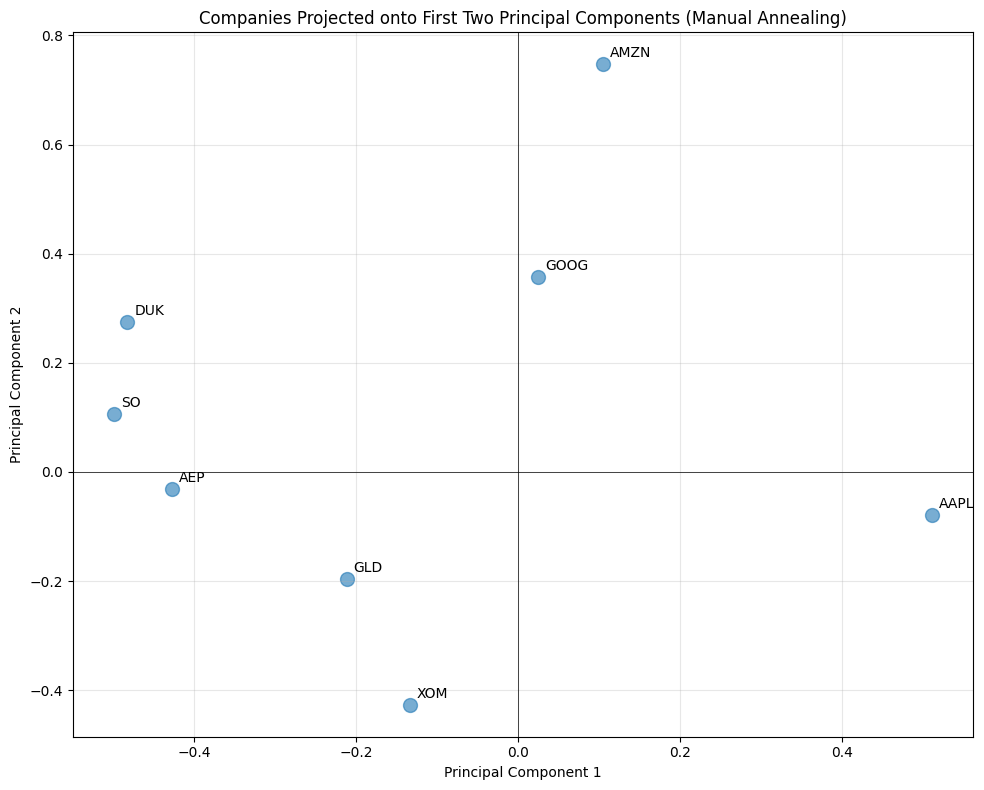


Finding 2 components using Dual Annealing

--- Component 1/2 ---
J_deflated diagonal sum: 0.045329
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: float64
b_i first 10 values: [ 1. -1.  1. -1. -1.  1. -1. -1.]
b_i unique values: [-1.  1.]
X_remaining norm BEFORE deflation: 0.212905
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.126457
X_remaining norm AFTER deflation: 0.171281

--- Component 2/2 ---
J_deflated diagonal sum: 0.029337
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: float64
b_i first 10 values: [-1.  1.  1.  1. -1.  1.  1. -1.]
b_i unique values: [-1.  1.]
X_remaining norm BEFORE deflation: 0.171281
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.093067
X_remaining norm AFTER deflation: 0.143791
Projection of X_remaining onto previous component: 0.000000

Co

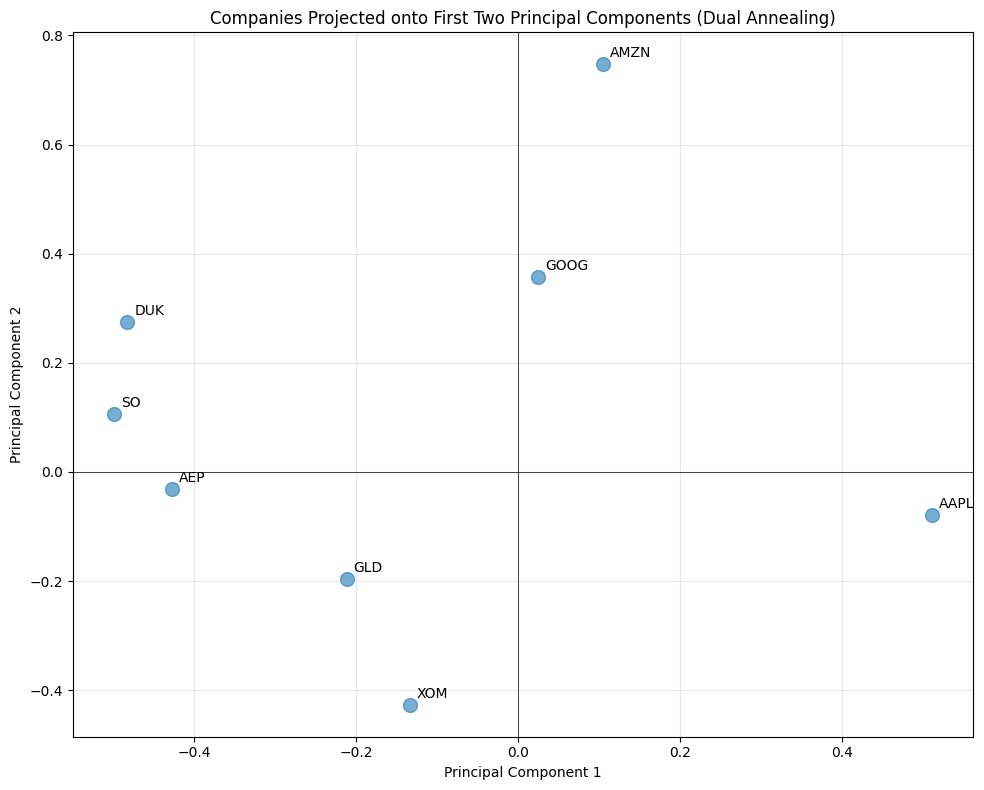


Finding 2 components using Quantum Annealing

--- Component 1/2 ---
J_deflated diagonal sum: 0.045329
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: int8
b_i first 10 values: [ 1 -1  1 -1 -1  1 -1 -1]
b_i unique values: [-1  1]
X_remaining norm BEFORE deflation: 0.212905
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.126457
X_remaining norm AFTER deflation: 0.171281

--- Component 2/2 ---
J_deflated diagonal sum: 0.029337
b_i type: <class 'numpy.ndarray'>
b_i shape: (8,)
b_i dtype: int8
b_i first 10 values: [-1  1  1  1 -1  1  1 -1]
b_i unique values: [-1  1]
X_remaining norm BEFORE deflation: 0.171281
b_i norm (before normalization): 2.828427
b_i_normalized norm: 1.000000
b_i_col shape: (8, 1)
b_i @ b_i.T shape: (8, 8)
deflation_term norm: 0.093067
X_remaining norm AFTER deflation: 0.143791
Projection of X_remaining onto previous component: 0.000000

Computing total energy fr

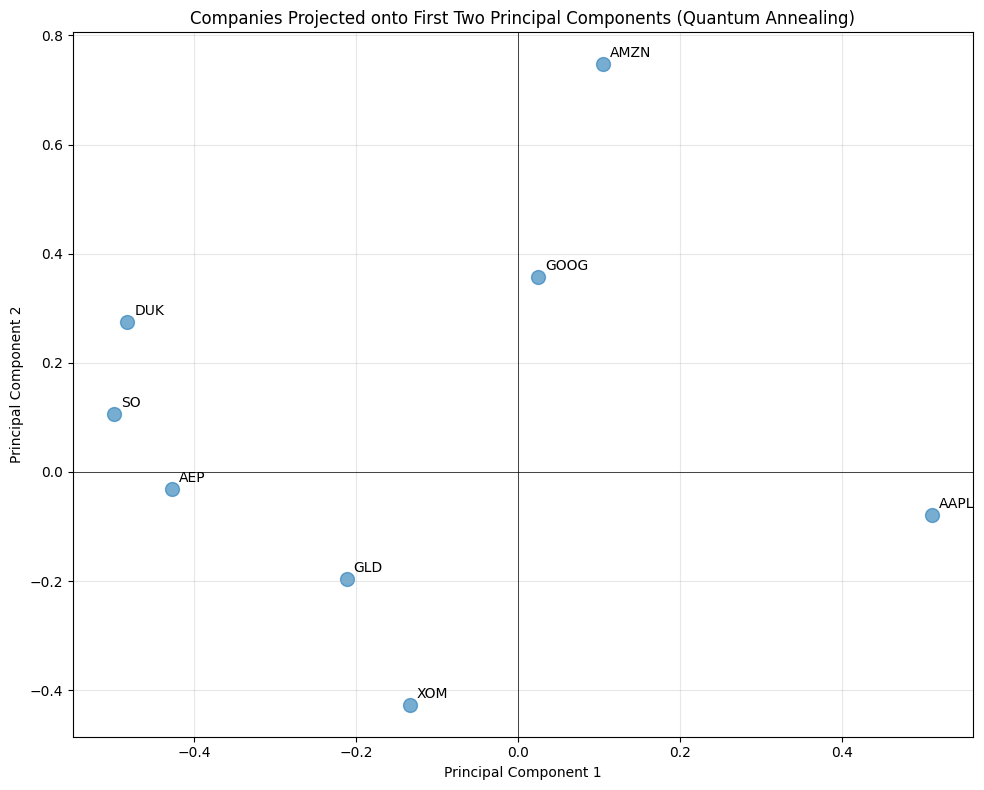


=== L2 PCA (Eigendecomposition) ===
Binary b vectors (shape (2, 8)):
[[-0.50951306  0.4246857  -0.08453354  0.4847993   0.22194185 -0.01376459
   0.50087932  0.1324178 ]
 [ 0.32033273  0.05522111  0.84359153  0.18121585  0.02183092  0.27105357
   0.19139152  0.19817762]]

Actual PCA components (shape (8, 2)):
[[-0.50951306  0.32033273]
 [ 0.4246857   0.05522111]
 [-0.08453354  0.84359153]
 [ 0.4847993   0.18121585]
 [ 0.22194185  0.02183092]
 [-0.01376459  0.27105357]
 [ 0.50087932  0.19139152]
 [ 0.1324178   0.19817762]]

Best energy: -0.0007873380962917003

Individual component energies:
  Component 1: -0.0005744473157940333
  Component 2: -0.00021289078049766688


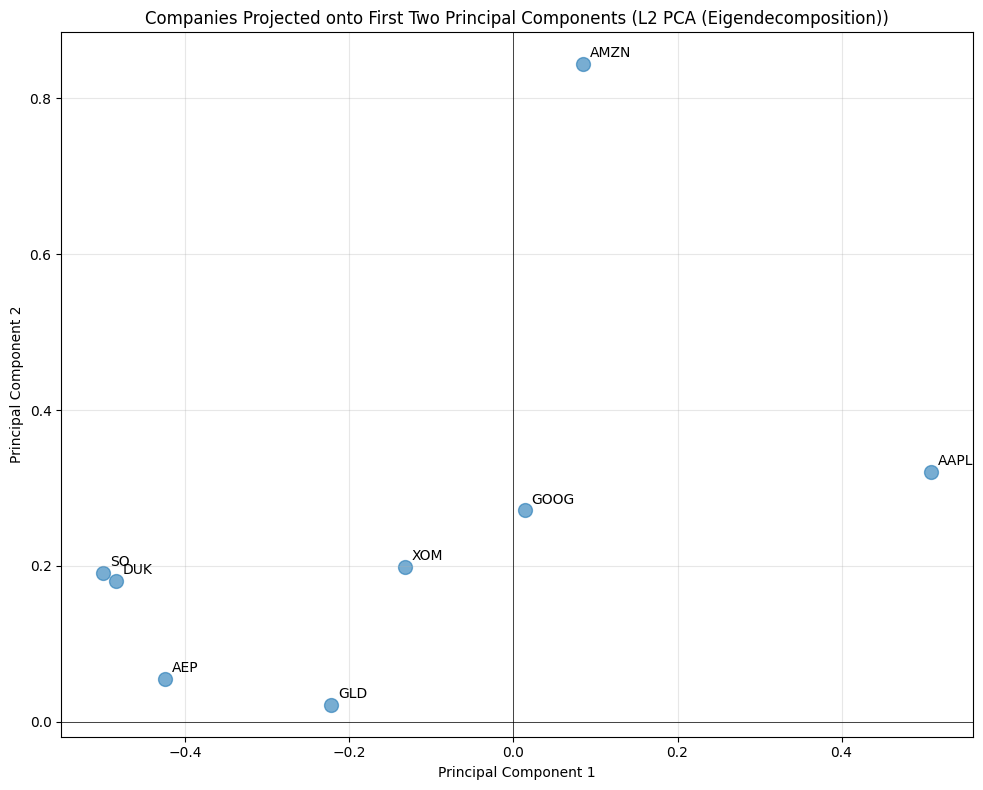

J shape: (8, 8)
X shape: (8, 37)
B type: <class 'numpy.ndarray'>
B shape: (8, 2)
B shape after check: (8, 2)
XB shape: (37, 2)

=== Multi-Component QAPCA (K=2) ===
Binary b vectors (shape (2, 8)):
[[-1  1 -1  1  1 -1  1  1]
 [-1  1 -1  1  1 -1  1  1]]

Actual PCA components (shape (8, 2)):
[[-0.51371007 -0.454895  ]
 [ 0.376933    0.45637678]
 [-0.39493143 -0.03897458]
 [ 0.40751893  0.44610695]
 [ 0.13884962  0.31961307]
 [-0.13487791 -0.02127736]
 [ 0.42479555  0.50816205]
 [ 0.2325047   0.15305697]]

Best energy: -0.007104151891452229


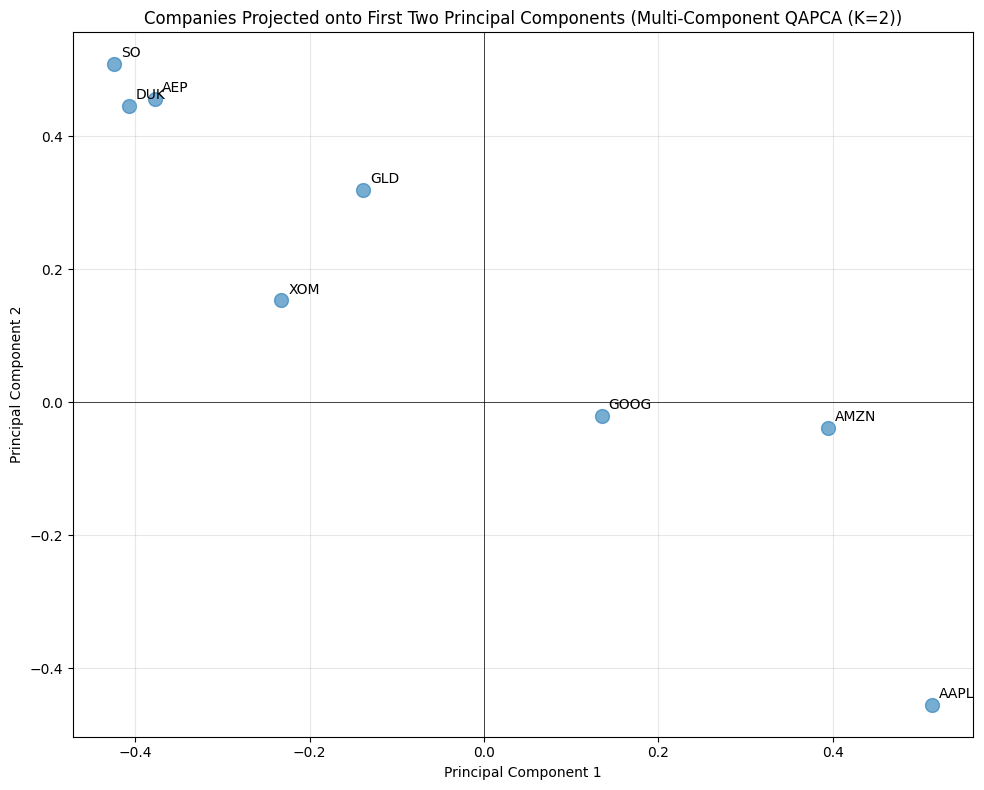

In [ ]:
#Manual annealing (method 0)
manual_results = find_k_b_vectors(2, data, method=0)
calculate_pca_from_b_vectors(manual_results, data)
print_results(manual_results)
plot_companies_in_pc_space(data, manual_results)

#Dual annealing (method 1)
dual_results = find_k_b_vectors(2, data, method=1)
calculate_pca_from_b_vectors(dual_results, data)
print_results(dual_results)
plot_companies_in_pc_space(data, dual_results)

#Quantum annealing (method 2)
quantum_results = find_k_b_vectors(2, data, method=2)
calculate_pca_from_b_vectors(quantum_results, data)
print_results(quantum_results)
plot_companies_in_pc_space(data, quantum_results)

#L2 PCA (eigendecomposition)
l2_results = solve_l2_pca(data, n_components=2)
print_results(l2_results)
plot_companies_in_pc_space(data, l2_results)

#ML SKlearn PCA 
ml_results = run_ml_pca(price_df)
print(f"ML PCA Components shape: {ml_results.shape}")
plot_companies_in_pc_space(data, ml_results)

# Multi Component results 
multi_results = solve_multi_component_qapca_wrapper(data, n_components=2)
print_results(multi_results)
plot_companies_in_pc_space(data, multi_results)

In [ ]:
#Find Quantum Music Data from Classical Component as same values as Quantum Component 
pca_embeddings = solve_l1_classical_component(log_returns.values.T, 2, solve_l1_classical_component)

prin_component1 = pca_embeddings[:, 0] 
prin_component2 = pca_embeddings[:, 1]  


tickers = ['GOOG', 'XOM', 'AAPL', 'AMZN', 'GLD', 'DUK', 'SO', 'AEP']
sectors = {
    'GOOG': 'Technology', 'AAPL': 'Technology', 'AMZN': 'Technology', 
    'XOM': 'Energy', 'GLD': 'Finance', 'DUK': 'Utility', 'SO': 'Utility', 'AEP': 'Utility'
}

pc1_min, pc1_max = prin_component1.min(), prin_component1.max()
pc2_min, pc2_max = prin_component2.min(), prin_component2.max()

print(f"PC1 Range: [{pc1_min:.3f}, {pc1_max:.3f}]")
print(f"PC2 Range: [{pc2_min:.3f}, {pc2_max:.3f}]")
print()


for i, ticker in enumerate(tickers):
    pc1 = prin_component1[i]
    pc2 = prin_component2[i]
    
    pitch = int(48 + ((pc1 - pc1_min) / (pc1_max - pc1_min)) * 24)      # PC1 → Pitch (48-72)
    duration = 0.5 + ((pc2 - pc2_min) / (pc2_max - pc2_min)) * 2        # PC2 → Duration (0.5-2.5)
    velocity = int(60 + ((pc1 - pc1_min) / (pc1_max - pc1_min)) * 40)   # PC1 → Volume (60-100)
    
    print(f"{ticker}:")
    print(f"  Pitch: {pitch}")
    print(f"  Duration: {duration:.1f}")
    print(f"  Velocity: {velocity}")
    print(f"  Sector: {sectors[ticker]}")
    print(f"  PC1: {pc1:.3f}")
    print(f"  PC2: {pc2:.3f}")
    print()


In [ ]:
#Implement Quantum Music with Midi and garageband 

music_data = {
    'GOOG': {'pitch': 72, 'duration': 2.5, 'velocity': 100, 'sector': 'Technology', 'pc1': 0.469, 'pc2': 0.469},
    'XOM': {'pitch': 49, 'duration': 0.6, 'velocity': 62, 'sector': 'Energy', 'pc1': -0.397, 'pc2': -0.397},
    'AAPL': {'pitch': 69, 'duration': 2.3, 'velocity': 95, 'sector': 'Technology', 'pc1': 0.374, 'pc2': 0.374},
    'AMZN': {'pitch': 49, 'duration': 0.7, 'velocity': 63, 'sector': 'Technology', 'pc1': -0.390, 'pc2': -0.390},
    'GLD': {'pitch': 54, 'duration': 1.1, 'velocity': 71, 'sector': 'Finance', 'pc1': -0.190, 'pc2': -0.190},
    'DUK': {'pitch': 65, 'duration': 1.9, 'velocity': 88, 'sector': 'Utility', 'pc1': 0.206, 'pc2': 0.206},
    'SO': {'pitch': 48, 'duration': 0.5, 'velocity': 60, 'sector': 'Utility', 'pc1': -0.461, 'pc2': -0.461},
    'AEP': {'pitch': 54, 'duration': 1.1, 'velocity': 71, 'sector': 'Utility', 'pc1': -0.199, 'pc2': -0.199}
}

def create_quantum_music(music_data, filename="quantum_pca_music.mid"):
    midi = MIDIFile(1)
    tempo = 120
    
    midi.addTrackName(0, 0, "Quantum PCA Music")
    midi.addTempo(0, 0, tempo)
    midi.addProgramChange(0, 0, 0, 1)  #use piano 
    
    print("Quantum State Analysis (Continuous Values):")
    high_pc1_stocks = [ticker for ticker, data in music_data.items() if data['pc1'] > 0.3]
    medium_pc1_stocks = [ticker for ticker, data in music_data.items() if -0.2 <= data['pc1'] <= 0.3]
    low_pc1_stocks = [ticker for ticker, data in music_data.items() if data['pc1'] < -0.2]
    
    print(f"High PC1 (>0.3): {high_pc1_stocks}")
    print(f"Medium PC1 (-0.2 to 0.3): {medium_pc1_stocks}")
    print(f"Low PC1 (<-0.2): {low_pc1_stocks}")
    
    #use sequential composition
    time = 0
    
    #pattern 1: Play stocks in order of PC1 (high to low)
    print("Pattern 1: PC1 Gradient")
    stocks_by_pc1 = sorted(music_data.keys(), key=lambda x: music_data[x]['pc1'], reverse=True)
    
    for ticker in stocks_by_pc1:
        data = music_data[ticker]
        midi.addNote(0, 0, data['pitch'], time, data['duration'], data['velocity'])
        print(f"  {ticker}: pitch={data['pitch']}, time={time}, duration={data['duration']}")
        time += data['duration'] 
    
    #pattern 2: Group by sector
    print("Pattern 2: Sector Groups")
    time += 2.0  #add rest between patterns
    
    sectors = {}
    for ticker, data in music_data.items():
        sector = data['sector']
        if sector not in sectors:
            sectors[sector] = []
        sectors[sector].append(ticker)
    
    for sector, stocks in sectors.items():
        print(f"  {sector} sector: {stocks}")
        for ticker in stocks:
            data = music_data[ticker]
            midi.addNote(0, 0, data['pitch'], time, data['duration'] * 0.7, data['velocity'])
            time += data['duration'] * 0.5
    
    #pattern 3: Final chord with all stocks
    print("Pattern 3: Quantum Chord")
    time += 2.0
    
    for ticker, data in music_data.items():
        midi.addNote(0, 0, data['pitch'], time, 4.0, data['velocity'])
    
    try:
        with open(filename, "wb") as output_file:
            midi.writeFile(output_file)
        print(f"SUCCESS: MIDI file saved as '{filename}'")
        return filename
    except Exception as e:
        print(f" ERROR saving MIDI file: {e}")
        return None

#music generation
output_file = create_quantum_music(music_data)


In [ ]:
def plot_all_methods_comparison(results_df, title="Objective Value vs Number of Assets Across Methods", 
                                 figsize=(14, 8), show_legend=True, save_path=None):
    """
    Plot all methods on a single line graph with different colors.
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        Results from analyze_objective_convergence with columns: [n_assets, method, objective_value]
    title : str
        Plot title
    figsize : tuple
        Figure size (width, height)
    show_legend : bool
        Whether to show legend
    save_path : str, optional
        Path to save figure (e.g., 'comparison.png')
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    #check methods and do that
    methods = results_df['method'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    for method, color in zip(methods, colors):
        method_data = results_df[results_df['method'] == method].sort_values('n_assets')
        
        #remove NaN values
        valid_data = method_data.dropna(subset=['objective_value'])
        
        ax.plot(valid_data['n_assets'], 
                valid_data['objective_value'], 
                marker='o', 
                label=method, 
                linewidth=2.5, 
                markersize=8, 
                color=color,
                alpha=0.8)
        
    ax.set_xlabel('Number of Assets', fontsize=13, fontweight='bold')
    ax.set_ylabel('Objective Value (Energy)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    if show_legend:
        ax.legend(fontsize=11, loc='best', framealpha=0.9)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig, ax


"\n# Define your methods\nmethods_to_compare = {\n    'L2 PCA': lambda d, n: solve_l2_pca(d, n),\n    'L1 PCA': lambda d, n: solve_l1_pca(d, n, max_iter=1000),\n    'Quantum Annealing': lambda d, n: solve_quantum_annealing(d, n, num_reads=1000),\n    'Simulated Annealing': lambda d, n: solve_simulated_annealing(d, n, max_iter=1000)\n}\n\n# Run analysis\nasset_counts = [3, 5, 7, 9, 12, 15, 18, 20]\nresults_df = analyze_objective_convergence(\n    data=returns, \n    asset_counts=asset_counts,\n    methods_dict=methods_to_compare,\n    n_iterations=1000,\n    n_components=2\n)\n\n# Create the comparison plot\nplot_all_methods_comparison(results_df, save_path='methods_comparison.png')\n\n# Optional: Print the data\nprint(results_df)\n"

In [15]:


def get_very_large_stock_data(start_date='2017-01-01', end_date='2017-03-01', n_stocks=100):
    
    #Top 100 S&P 500 stocks by market cap (as of 2017) used forsector clustering demos
    if n_stocks >= 100:
        tickers = [
            #Mega Cap Technology (15)
            'AAPL', 'MSFT', 'GOOG', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA',
            'INTC', 'AMD', 'CSCO', 'ORCL', 'IBM', 'QCOM', 'AVGO',
            
            #Large Cap Technology (10)
            'TXN', 'ADBE', 'CRM', 'INTU', 'AMAT', 'ADI', 'LRCX', 'KLAC', 
            'SNPS', 'CDNS',
            
            #Finance (15)
            'JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'SCHW', 'AXP', 'USB',
            'PNC', 'TFC', 'COF', 'BK', 'STT',
            
            #Healthcare (15)
            'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'MRK', 'ABT', 'DHR', 'BMY', 'LLY',
            'AMGN', 'GILD', 'CVS', 'CI', 'HUM',
            
            #Consumer Discretionary (12)
            'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'TGT', 'TJX', 'MAR', 'GM', 'F',
            'CMG', 'YUM',
            
            #Consumer Staples (10)
            'WMT', 'PG', 'KO', 'PEP', 'COST', 'CL', 'MDLZ', 'MO', 'GIS', 'KHC',
            
            #Energy (8)
            'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PXD', 'VLO', 'PSX',
            
            #Utilities (5)
            'DUK', 'SO', 'AEP', 'NEE', 'D',
            
            #Industrials (10)
            'BA', 'UNP', 'HON', 'UPS', 'CAT', 'DE', 'MMM', 'GE', 'LMT', 'RTX'
        ]
    elif n_stocks >= 75:
        tickers = [
            # Technology (20)
            'AAPL', 'MSFT', 'GOOG', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA',
            'INTC', 'AMD', 'CSCO', 'ORCL', 'IBM', 'QCOM', 'AVGO', 'TXN', 
            'ADBE', 'CRM', 'INTU', 'AMAT',
            
            # Finance (15)
            'JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'SCHW', 'AXP', 'USB',
            'PNC', 'TFC', 'COF', 'BK', 'STT',
            
            # Healthcare (15)
            'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'MRK', 'ABT', 'DHR', 'BMY', 'LLY',
            'AMGN', 'GILD', 'CVS', 'CI', 'HUM',
            
            # Consumer (12)
            'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'TGT', 'WMT', 'PG', 'KO', 'PEP', 
            'COST', 'CL',
            
            # Energy (6)
            'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PXD',
            
            # Utilities & Industrials (7)
            'DUK', 'SO', 'AEP', 'NEE', 'BA', 'UNP', 'HON'
        ]
    else:  # 50 stocks
        tickers = [
            # Technology (12)
            'AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'INTC', 'AMD', 
            'CSCO', 'ORCL', 'IBM', 'QCOM',
            
            # Finance (10)
            'JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'SCHW', 'AXP', 'USB',
            
            # Healthcare (10)
            'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'MRK', 'ABT', 'DHR', 'BMY', 'LLY',
            
            # Consumer Discretionary (7)
            'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'TGT',
            
            # Consumer Staples (7)
            'WMT', 'PG', 'KO', 'PEP', 'COST', 'CL', 'MDLZ',
            
            # Energy (4)
            'XOM', 'CVX', 'COP', 'SLB'
        ]
    
    print(f"Downloading {len(tickers)} stocks from {start_date} to {end_date}...")
    ticker_data = yf.download(tickers, start=start_date, end=end_date, 
                              group_by="ticker", auto_adjust=True, progress=True)
    ticker_data = ticker_data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()
    price_df = ticker_data.pivot(index="Date", columns="Ticker", values="Close")
    price_df = price_df.dropna(axis=1, thresh=len(price_df) * 0.9)
    returns = (price_df / price_df.shift(1) - 1).dropna()
    
    print(f"Successfully downloaded: {returns.shape[0]} days × {returns.shape[1]} stocks")
    print(f"Stocks: {list(returns.columns)}")
    
    # Create comprehensive sector mapping
    sectors = create_sector_mapping(returns.columns)
    
    return returns, sectors


def create_sector_mapping(tickers):
    """
    Create sector mapping for common tickers.
    """
    sector_map = {
        # Technology
        'AAPL': 'Technology', 'MSFT': 'Technology', 'GOOG': 'Technology', 
        'GOOGL': 'Technology', 'AMZN': 'Technology', 'META': 'Technology', 
        'NVDA': 'Technology', 'INTC': 'Technology', 'AMD': 'Technology',
        'CSCO': 'Technology', 'ORCL': 'Technology', 'IBM': 'Technology',
        'QCOM': 'Technology', 'AVGO': 'Technology', 'TXN': 'Technology',
        'ADBE': 'Technology', 'CRM': 'Technology', 'INTU': 'Technology',
        'AMAT': 'Technology', 'ADI': 'Technology', 'LRCX': 'Technology',
        'KLAC': 'Technology', 'SNPS': 'Technology', 'CDNS': 'Technology',
        
        # Finance
        'JPM': 'Finance', 'BAC': 'Finance', 'WFC': 'Finance', 'GS': 'Finance',
        'MS': 'Finance', 'C': 'Finance', 'BLK': 'Finance', 'SCHW': 'Finance',
        'AXP': 'Finance', 'USB': 'Finance', 'PNC': 'Finance', 'TFC': 'Finance',
        'COF': 'Finance', 'BK': 'Finance', 'STT': 'Finance',
        
        # Healthcare
        'JNJ': 'Healthcare', 'UNH': 'Healthcare', 'PFE': 'Healthcare',
        'ABBV': 'Healthcare', 'TMO': 'Healthcare', 'MRK': 'Healthcare',
        'ABT': 'Healthcare', 'DHR': 'Healthcare', 'BMY': 'Healthcare',
        'LLY': 'Healthcare', 'AMGN': 'Healthcare', 'GILD': 'Healthcare',
        'CVS': 'Healthcare', 'CI': 'Healthcare', 'HUM': 'Healthcare',
        
        # Consumer Discretionary
        'TSLA': 'Consumer Disc', 'HD': 'Consumer Disc', 'MCD': 'Consumer Disc',
        'NKE': 'Consumer Disc', 'SBUX': 'Consumer Disc', 'LOW': 'Consumer Disc',
        'TGT': 'Consumer Disc', 'TJX': 'Consumer Disc', 'MAR': 'Consumer Disc',
        'GM': 'Consumer Disc', 'F': 'Consumer Disc', 'CMG': 'Consumer Disc',
        'YUM': 'Consumer Disc',
        
        # Consumer Staples
        'WMT': 'Consumer Staples', 'PG': 'Consumer Staples', 'KO': 'Consumer Staples',
        'PEP': 'Consumer Staples', 'COST': 'Consumer Staples', 'CL': 'Consumer Staples',
        'MDLZ': 'Consumer Staples', 'MO': 'Consumer Staples', 'GIS': 'Consumer Staples',
        'KHC': 'Consumer Staples',
        
        # Energy
        'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'SLB': 'Energy',
        'EOG': 'Energy', 'PXD': 'Energy', 'VLO': 'Energy', 'PSX': 'Energy',
        
        # Utilities
        'DUK': 'Utility', 'SO': 'Utility', 'AEP': 'Utility', 'NEE': 'Utility',
        'D': 'Utility',
        
        # Industrials
        'BA': 'Industrials', 'UNP': 'Industrials', 'HON': 'Industrials',
        'UPS': 'Industrials', 'CAT': 'Industrials', 'DE': 'Industrials',
        'MMM': 'Industrials', 'GE': 'Industrials', 'LMT': 'Industrials',
        'RTX': 'Industrials'
    }
    
    # Return only sectors for tickers that exist
    return {ticker: sector_map.get(ticker, 'Unknown') for ticker in tickers}




In [ ]:

returns_data, sectors_data = get_very_large_stock_data(n_stocks=50)

def analyze_objective_convergence(data, asset_counts, methods_dict, n_iterations=1000, 
                                   n_components=2, random_seed=42):
    """
    Analyze how objective values change with number of assets for different PCA methods.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        Stock returns data (days × stocks)
    asset_counts : list of int
        List of asset counts to test (e.g., [3, 5, 7, 9, 12, 15])
    methods_dict : dict
        Dictionary mapping method names to solver functions
        Example: {
            'L2 PCA': solve_l2_pca,
            'L1 PCA': lambda d, n: solve_l1_pca(d, n, max_iter=n_iterations),
        }
    n_iterations : int
        Fixed number of iterations/reads for iterative methods
    n_components : int
        Number of principal components
    random_seed : int
        Random seed for reproducible asset selection
        
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with columns: [n_assets, method, objective_value]
    """
    
    np.random.seed(random_seed)
    
    results = []
    max_assets = data.shape[1]
    
    for n_assets in asset_counts:
        if n_assets > max_assets:
            print(f"Skipping n_assets={n_assets} (exceeds available {max_assets} assets)")
            continue
            
        print(f"\nTesting with {n_assets} assets...")
        
        #select subset of assets (first n_assets columns for consistency) and run each method to extract objective value
        subset_data = data.iloc[:, :n_assets]
        
        for method_name, solver_func in methods_dict.items():
            try:
                print(f"  Running {method_name}...")

                result_container = solver_func(subset_data, n_components)
                
                objective_value = result_container.best_energy
                
                results.append({
                    'n_assets': n_assets,
                    'method': method_name,
                    'objective_value': objective_value
                })
                
                print(f"    Objective: {objective_value:.6f}")
                
            except Exception as e:
                print(f"    ERROR in {method_name}: {str(e)}")
                results.append({
                    'n_assets': n_assets,
                    'method': method_name,
                    'objective_value': np.nan
                })
    
    results_df = pd.DataFrame(results)
    return results_df



def plot_all_methods_comparison(results_df, title="Objective Value vs Number of Assets Across Methods", 
                                 figsize=(14, 8), show_legend=True, save_path=None):
    
    "repeat previous method that was used but for expanded dataset and more stuff"

    fig, ax = plt.subplots(figsize=figsize)
    methods = results_df['method'].unique()

    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

    for method, color in zip(methods, colors):
        method_data = results_df[results_df['method'] == method].sort_values('n_assets')
        
        # Remove NaN values
        valid_data = method_data.dropna(subset=['objective_value'])
        
        ax.plot(valid_data['n_assets'], 
                valid_data['objective_value'], 
                marker='o', 
                label=method, 
                linewidth=2.5, 
                markersize=8, 
                color=color,
                alpha=0.8)

    ax.set_xlabel('Number of Assets', fontsize=13, fontweight='bold')
    ax.set_ylabel('Objective Value (Energy)', fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    if show_legend:
        ax.legend(fontsize=11, loc='best', framealpha=0.9)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(labelsize=11)
    

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig, ax


def plot_objective_divergence(results_df, baseline_method=None, figsize=(16, 6)):
    """
    Plot the divergence (difference) from a baseline method.
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        Results from analyze_objective_convergence
    baseline_method : str, optional
        Method to use as baseline (default: first method alphabetically)
    figsize : tuple
        Figure size (width, height)
    """
    if baseline_method is None:
        baseline_method = sorted(results_df['method'].unique())[0]
    
    #get baseline values 
    baseline_data = results_df[results_df['method'] == baseline_method].copy()
    baseline_data = baseline_data.set_index('n_assets')['objective_value']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    #plot 1: Absolute difference from baseline
    methods = [m for m in results_df['method'].unique() if m != baseline_method]
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    
    for method, color in zip(methods, colors):
        method_data = results_df[results_df['method'] == method].copy()
        method_data = method_data.set_index('n_assets')
        
        diff = method_data['objective_value'] - baseline_data
        ax1.plot(diff.index, diff.values, marker='o', label=method, 
                linewidth=2, markersize=8, color=color)
    
    ax1.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('Number of Assets', fontsize=12)
    ax1.set_ylabel(f'Objective Difference from {baseline_method}', fontsize=12)
    ax1.set_title('Absolute Divergence from Baseline', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    #plot 2: Relative percentage difference
    for method, color in zip(methods, colors):
        method_data = results_df[results_df['method'] == method].copy()
        method_data = method_data.set_index('n_assets')
        
        #make sure to avoid division by 0
        rel_diff = 100 * (method_data['objective_value'] - baseline_data) / np.abs(baseline_data)
        ax2.plot(rel_diff.index, rel_diff.values, marker='o', label=method,
                linewidth=2, markersize=8, color=color)
    
    ax2.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Number of Assets', fontsize=12)
    ax2.set_ylabel(f'% Difference from {baseline_method}', fontsize=12)
    ax2.set_title('Relative Divergence from Baseline', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig, (ax1, ax2)



'\n# Step 1: Load expanded stock data\n\n# OR for larger dataset:\n# returns = get_large_stock_data(start_date=\'2017-01-01\', end_date=\'2017-03-01\')\n\n# Step 2: Define methods to compare (adjust function names to match your implementation)\n\n\n# Step 3: Define asset counts to test\n\n# Step 4: Run convergence analysis\n\n\n# Step 5: Plot all methods comparison\nplot_all_methods_comparison(results_df, save_path=\'methods_comparison.png\')\n\n# Step 6 (Optional): Plot divergence from baseline\nplot_objective_divergence(results_df, baseline_method=\'L2 PCA\')\n\n# Step 7 (Optional): Print summary statistics\nprint("\nSummary Statistics:")\nprint(results_df.groupby(\'method\')[\'objective_value\'].describe())\n\n# Step 8 (Optional): Save results to CSV\nresults_df.to_csv(\'convergence_results.csv\', index=False)\nprint("\nResults saved to convergence_results.csv")\n'

In [ ]:
def compare_all_methods_side_by_side(data, methods_dict, sectors=None, n_components=2):
    """Run all methods and plot them side-by-side for visual comparison."""
    
    n_methods = len(methods_dict)
    
    #create grid based on number of methods 
    if n_methods <= 4:
        nrows, ncols = 2, 2
    elif n_methods <= 6:
        nrows, ncols = 2, 3
    elif n_methods <= 9:
        nrows, ncols = 3, 3
    else:
        nrows, ncols = 4, 3
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    axes = axes.flatten()
    
    
    #default sectors and default color mapping
    if sectors is None:
        sectors = {ticker: 'Unknown' for ticker in data.columns}

    unique_sectors = list(set(sectors.values()))
    colors_map = {sector: plt.cm.tab10(i) for i, sector in enumerate(unique_sectors)}
    
    for idx, (method_name, solver_func) in enumerate(methods_dict.items()):
        if idx >= len(axes):
            break
            
        print(f"\nRunning {method_name}...")
        ax = axes[idx]
        
        try:
            results = solver_func(data, n_components)
            
            #calculate PCA components if needed
            if results.pca_components is None:
                results = calculate_pca_from_b_vectors(results, data)
            
            pca_components = results.pca_components
            pc1 = pca_components[:, 0]
            pc2 = pca_components[:, 1]
            
            ticker_names = data.columns
            plotted_sectors = set()
            
            for i, ticker in enumerate(ticker_names):
                sector = sectors.get(ticker, 'Unknown')
                color = colors_map[sector]
                
                label = sector if sector not in plotted_sectors else None
                if label:
                    plotted_sectors.add(sector)
                
                ax.scatter(pc1[i], pc2[i], color=color, s=100, alpha=0.7, label=label)
                ax.annotate(ticker, (pc1[i], pc2[i]), 
                           xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            #print energy
            print(f"  Energy: {results.best_energy:.6f}")

            ax.set_xlabel('PC1', fontsize=11, fontweight='bold')
            ax.set_ylabel('PC2', fontsize=11, fontweight='bold')
            ax.set_title(f'{method_name}\nEnergy: {results.best_energy:.4f}', 
                        fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, loc='best')
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.5)
            ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.5)
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            ax.text(0.5, 0.5, f'ERROR:\n{str(e)}', 
                   transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{method_name} - FAILED', fontsize=12, fontweight='bold')
    
    #hide unused subplots 
    for idx in range(len(methods_dict), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return fig, axes


Testing epsilon=0.001
J shape: (15, 15)
X shape: (15, 38)
B type: <class 'numpy.ndarray'>
B shape: (15, 2)
B shape after check: (15, 2)
XB shape: (38, 2)
  Energy: -0.003612
  PC1 == PC2? True

Testing epsilon=0.05
J shape: (15, 15)
X shape: (15, 38)
B type: <class 'numpy.ndarray'>
B shape: (15, 2)
B shape after check: (15, 2)
XB shape: (38, 2)
  Energy: -0.003612
  PC1 == PC2? True

Testing epsilon=0.1
J shape: (15, 15)
X shape: (15, 38)
B type: <class 'numpy.ndarray'>
B shape: (15, 2)
B shape after check: (15, 2)
XB shape: (38, 2)
  Energy: -0.003612
  PC1 == PC2? True

Testing epsilon=1
J shape: (15, 15)
X shape: (15, 38)
B type: <class 'numpy.ndarray'>
B shape: (15, 2)
B shape after check: (15, 2)
XB shape: (38, 2)
  Energy: -0.003612
  PC1 == PC2? True

Testing epsilon=1.9
J shape: (15, 15)
X shape: (15, 38)
B type: <class 'numpy.ndarray'>
B shape: (15, 2)
B shape after check: (15, 2)
XB shape: (38, 2)
  Energy: -0.003798
  PC1 == PC2? True

Testing epsilon=2
J shape: (15, 15)
X 

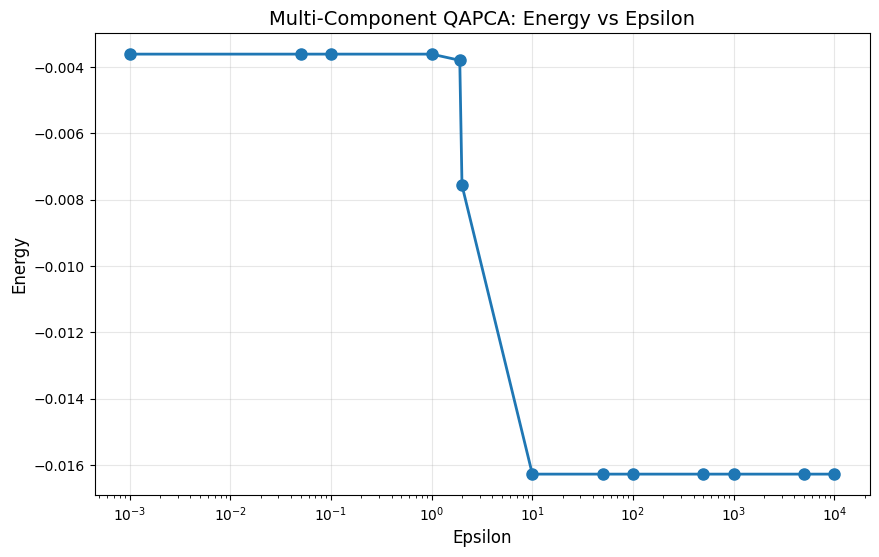


Best epsilon: 0.001
Best energy: -0.003612


In [ ]:
# Function used to optimize epsilon for best multi-component return. 

def test_epsilon_values(data, n_components=2, num_reads=1000):
    """
    Test different epsilon values to find best one.
    """
    epsilon_values = [0.001, 0.05, 0.1, 1, 1.9, 2, 10, 50, 100, 500, 1000, 5000, 10000]
    
    results = []
    for eps in epsilon_values:
        print(f"\nTesting epsilon={eps}")
        result = solve_multi_component_qapca_wrapper(
            data, 
            n_components=n_components, 
            epsilon=eps, 
            num_reads=num_reads
        )
        
        results.append({
            'epsilon': eps,
            'energy': result.best_energy,
            'pc1': result.b_vectors[0],
            'pc2': result.b_vectors[1],
            'identical': np.array_equal(result.b_vectors[0], result.b_vectors[1])
        })
        
        print(f"  Energy: {result.best_energy:.6f}")
        print(f"  PC1 == PC2? {results[-1]['identical']}")
    
    # Plot results
    import matplotlib.pyplot as plt
    eps_vals = [r['epsilon'] for r in results]
    energies = [r['energy'] for r in results]
    
    plt.figure(figsize=(10, 6))
    plt.semilogx(eps_vals, energies, 'o-', linewidth=2, markersize=8)
    plt.xlabel('Epsilon', fontsize=12)
    plt.ylabel('Energy', fontsize=12)
    plt.title('Multi-Component QAPCA: Energy vs Epsilon', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Find best
    best_idx = np.argmin([abs(r['energy']) for r in results])
    print(f"\nBest epsilon: {results[best_idx]['epsilon']}")
    print(f"Best energy: {results[best_idx]['energy']:.6f}")
    
    return results

# Test on small dataset first
test_data = returns.iloc[:, :15]
epsilon_results = test_epsilon_values(test_data, n_components=2, num_reads=1000)

In [ ]:
#test with dataset 

# Option 1: Load 50 stocks
print("=" * 70)
print("LOADING 50 STOCKS")
print("=" * 70)
returns_50, sectors_50 = get_very_large_stock_data(
    start_date='2017-01-01', 
    end_date='2017-03-01',
    n_stocks=50
)

# Your corrected methods dictionary
methods_to_compare = {
    'L2 PCA': lambda d, n: solve_l2_pca(d, n),
    'L1 Manual Annealing': lambda d, n: find_k_b_vectors(n, d, method=0),
    'L1 Quantum Annealing': lambda d, n: find_k_b_vectors(n, d, method=2),
    'L1 Dual Annealing': lambda d, n: find_k_b_vectors(n, d, method=1),
    'Multi-Component QAPCA': lambda d, n: solve_multi_component_qapca_wrapper(d, n, epsilon=10000, num_reads=100),
}

# Test with progressively larger subsets
print("\n" + "=" * 70)
print("TESTING WITH 15 STOCKS")
print("=" * 70)
test_15 = returns_50.iloc[:, :15]
sectors_15 = {k: v for k, v in sectors_50.items() if k in test_15.columns}
compare_all_methods_side_by_side(test_15, methods_to_compare, 
                                  sectors=sectors_15, n_components=2)

print("\n" + "=" * 70)
print("TESTING WITH 30 STOCKS")
print("=" * 70)
test_30 = returns_50.iloc[:, :30]
sectors_30 = {k: v for k, v in sectors_50.items() if k in test_30.columns}
compare_all_methods_side_by_side(test_30, methods_to_compare, 
                                  sectors=sectors_30, n_components=2)

print("\n" + "=" * 70)
print("TESTING WITH ALL 50 STOCKS")
print("=" * 70)
compare_all_methods_side_by_side(returns_50, methods_to_compare, 
                                  sectors=sectors_50, n_components=2)

In [ ]:
def compare_methods_over_N(data, methods_dict, N_values, k=2):
    """
    Run each L1/L2 PCA method for increasing numbers of N (e.g., number of stocks)
    and plot their objective function (best_energy) on the same graph.
    """

    results = {name: [] for name in methods_dict.keys()}

    for N in N_values:
        print(f"\n{'='*70}\nRunning all methods with N={N} stocks\n{'='*70}")
        subset = data.iloc[:, :N]

        for method_name, method_func in methods_dict.items():
            try:
                print(f"\n>>> Running {method_name} with N={N}")
                res = method_func(subset, k)

                #each result should have .best_energy
                if hasattr(res, 'best_energy') and res.best_energy is not None:
                    results[method_name].append(res.best_energy)
                    print(f"{method_name}: best_energy = {res.best_energy:.4f}")
                else:
                    results[method_name].append(np.nan)
                    print(f"{method_name}: ⚠ Missing best_energy, stored as NaN")

            except Exception as e:
                results[method_name].append(np.nan)
                print(f"{method_name} failed for N={N}: {e}")

    plt.figure(figsize=(10, 6))
    for method_name, energies in results.items():
        plt.plot(N_values, energies, marker='o', label=method_name)

    plt.title("Objective Function vs. N for Different PCA Methods")
    plt.xlabel("Number of Stocks (N)")
    plt.ylabel("Objective Function (best_energy)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results

N_values = [5, 10, 15, 20, 25, 30, 40, 50]

results_dict = compare_methods_over_N(
    data=returns_50,
    methods_dict=methods_to_compare,
    N_values=N_values,
    k=2
)

In [ ]:
def find_k_b_vectors_refactored(k, data, method='dual', max_iterations=10000, enforce_monotone=True):
    """
    Find k binary components using a specified annealing method and plot variance captured.
    """
    X = data.values.T 
    X_remaining = X.copy()
    J_original = X @ X.T
    components = []
    variances = []

    method_name = "Dual Annealing" if method == 'dual' else "Manual Annealing"
    overall_results = L1PCAResults(method_name)
    overall_results.X = X
    overall_results.J = J_original

    # Solver map
    solver_map = {
        'manual': lambda J: manual_anneal(J, max_iterations=max_iterations).b_vectors,
        'dual': lambda J: solve_l1_classical_component(J, X_remaining).b_vectors
    }
    if method not in solver_map:
        raise ValueError(f"Unknown method '{method}'")
    solver = solver_map[method]

    print(f"\n{'='*70}")
    print(f"Finding {k} components using {method_name}")
    print(f"{'='*70}")

    for i in range(k):
        print(f"\n--- Component {i+1}/{k} ---")
        J_deflated = X_remaining @ X_remaining.T

        b_i = solver(J_deflated).flatten()
        overall_results.individual_results.append(b_i.copy())
        components.append(b_i.copy())

        variance = float(b_i.T @ J_original @ b_i)
        variances.append(variance)
        print(f"Component {i+1} variance: {variance:.6f}")

        b_i_normalized = b_i / np.linalg.norm(b_i)
        X_remaining -= (b_i_normalized.reshape(-1,1) @ b_i_normalized.reshape(1,-1) @ X_remaining)

    components = np.array(components)
    variances = np.array(variances)

    #enforcing monotone decreasing variance
    if enforce_monotone:
        sorted_idx = np.argsort(-variances) 
        components = components[sorted_idx]
        variances = variances[sorted_idx]

    overall_results.b_vectors = components
    overall_results.best_energy = -sum(variances)


    plt.figure(figsize=(8,5))
    plt.plot(range(1, k+1), variances, 'o-', color='tab:red')
    plt.xlabel("Principal Component Number")
    plt.ylabel("Variance Captured (bᵀJb)")
    plt.title(f"Variance Captured by Each L1 Component ({method_name})")
    plt.grid(True)
    plt.show()

    return overall_results



find_k_b_vectors_dual_annealing(10, data)


In [ ]:
def plot_first_3_dual_annealing_3d(data, sectors=None):
    """
    Plot companies in 3D principal component space using dual annealing.

    """
    
    if sectors is None:
        sectors = {ticker: 'Unknown' for ticker in data.columns}
    
    #compute first 3 components using dual annealing
    results = find_k_b_vectors(k=3, data=data, method=1)
    
    #calculate PCA components (this should populate results.pca_components)
    calculate_pca_from_b_vectors(results, data)
    
    pca_components = results.pca_components
    
    if pca_components is None:
        print("No PCA components found. Run calculate_pca_from_b_vectors first.")
        return None, None
    
    if pca_components.shape[1] < 3:
        print("Need at least 3 principal components for 3D plot")
        return None, None
    
    pc1 = -pca_components[:, 0]  #First PC (flipped for visualization)
    pc2 = pca_components[:, 1]   #Second PC
    pc3 = pca_components[:, 2]   #Third PC

    ticker_names = data.columns
    

    unique_sectors = list(set(sectors.values()))
    colors_map = {sector: plt.cm.tab10(i % 10) for i, sector in enumerate(unique_sectors)}

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    plotted_sectors = set()
    
    for i, ticker in enumerate(ticker_names):
        sector = sectors.get(ticker, 'Unknown')
        color = colors_map[sector]
        label = sector if sector not in plotted_sectors else None
        if label:
            plotted_sectors.add(sector)
        
        ax.scatter(pc1[i], pc2[i], pc3[i], color=color, s=100, alpha=0.7, 
                  edgecolors='black', linewidths=0.5, label=label)
        ax.text(pc1[i], pc2[i], pc3[i], f' {ticker}', size=9, zorder=1, color='k')
    
    ax.set_xlabel('Principal Component 1', fontsize=11, fontweight='bold')
    ax.set_ylabel('Principal Component 2', fontsize=11, fontweight='bold')
    ax.set_zlabel('Principal Component 3', fontsize=11, fontweight='bold')
    ax.set_title(f'First 3 L1 Components (Dual Annealing)', fontsize=13, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    
    x_lim = ax.get_xlim()
    y_lim = ax.get_ylim()
    z_lim = ax.get_zlim()

    ax.plot([0, 0], [0, 0], z_lim, 'k-', linewidth=0.5, alpha=0.5)
    ax.plot([0, 0], y_lim, [0, 0], 'k-', linewidth=0.5, alpha=0.5)
    ax.plot(x_lim, [0, 0], [0, 0], 'k-', linewidth=0.5, alpha=0.5)

    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    #set viewing angle
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax


#Plot first 3 L1 components for subset of 15 stocks

test_15 = returns_50.iloc[:, :15]
sectors_15 = {k: v for k, v in sectors_50.items() if k in test_15.columns}

fig15, ax15 = plot_first_3_dual_annealing_3d(
    data=test_15,
    sectors=sectors_15
)


#Plot first 3 L1 components for subset of 30 stocks
test_30 = returns_50.iloc[:, :30]
sectors_30 = {k: v for k, v in sectors_50.items() if k in test_30.columns}

fig30, ax30 = plot_first_3_dual_annealing_3d(
    data=test_30,
    sectors=sectors_30
)


#Plot first 3 L1 components for all 50 stocks
fig, ax = plot_first_3_dual_annealing_3d(
    data=returns_50,      
    sectors=sectors_50   
)





In [ ]:
def compute_l1_pca_components(data, sectors=None, k=3):
    """
    Compute L1 PCA components ONCE - returns all necessary data for plotting.
    
    Parameters
    ----------
    data : pandas.DataFrame
        Stocks × days return data.
    sectors : dict
        Optional sector mapping {ticker: sector}.
    k : int
        Number of components to compute (default=3).
    
    Returns
    -------
    dict
        Dictionary containing all computed data needed for plotting.
    """
    import pandas as pd
    
    print("="*70)
    print(f"Computing {k} L1 PCA components using Dual Annealing")
    print("="*70)
    
    # Default sectors
    if sectors is None:
        sectors = {ticker: 'Unknown' for ticker in data.columns}
    
    # Compute components using dual annealing
    results = find_k_b_vectors(k=k, data=data, method=1)
    
    # Calculate PCA components
    calculate_pca_from_b_vectors(results, data)
    
    pca_components = results.pca_components
    
    if pca_components is None:
        print("ERROR: No PCA components found.")
        return None
    
    if pca_components.shape[1] < k:
        print(f"ERROR: Need at least {k} principal components")
        return None
    
    # Extract components
    pc1 = -pca_components[:, 0]
    pc2 = pca_components[:, 1]
    pc3 = pca_components[:, 2] if k >= 3 else None
    
    ticker_names = data.columns
    sector_list = [sectors.get(ticker, 'Unknown') for ticker in ticker_names]
    
    # Color mapping
    import matplotlib.pyplot as plt
    unique_sectors = list(set(sectors.values()))
    colors_map = {sector: plt.cm.tab10(i % 10) for i, sector in enumerate(unique_sectors)}
    
    # Create dataframe for easy access
    plot_df = pd.DataFrame({
        'PC1': pc1,
        'PC2': pc2,
        'PC3': pc3 if pc3 is not None else 0,
        'Ticker': ticker_names,
        'Sector': sector_list
    })
    
    print("\n" + "="*70)
    print("Components computed successfully!")
    print(f"PC1 range: [{pc1.min():.3f}, {pc1.max():.3f}]")
    print(f"PC2 range: [{pc2.min():.3f}, {pc2.max():.3f}]")
    if pc3 is not None:
        print(f"PC3 range: [{pc3.min():.3f}, {pc3.max():.3f}]")
    print("="*70 + "\n")
    
    return {
        'data': data,
        'results': results,
        'pca_components': pca_components,
        'pc1': pc1,
        'pc2': pc2,
        'pc3': pc3,
        'ticker_names': ticker_names,
        'sectors': sectors,
        'sector_list': sector_list,
        'colors_map': colors_map,
        'unique_sectors': unique_sectors,
        'plot_df': plot_df
    }


def plot_static_3d(computed_data):
    """
    Create static matplotlib 3D plot from pre-computed data.
    
    Parameters
    ----------
    computed_data : dict
        Dictionary returned by compute_l1_pca_components().
    
    Returns
    -------
    tuple
        (fig, ax) matplotlib figure and axis objects.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    print("Creating static matplotlib 3D plot...")
    
    # Extract data
    pc1 = computed_data['pc1']
    pc2 = computed_data['pc2']
    pc3 = computed_data['pc3']
    ticker_names = computed_data['ticker_names']
    sectors = computed_data['sectors']
    colors_map = computed_data['colors_map']
    
    # Create figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    plotted_sectors = set()
    
    for i, ticker in enumerate(ticker_names):
        sector = sectors.get(ticker, 'Unknown')
        color = colors_map[sector]
        label = sector if sector not in plotted_sectors else None
        if label:
            plotted_sectors.add(sector)
        
        ax.scatter(pc1[i], pc2[i], pc3[i], color=color, s=100, alpha=0.7, 
                  edgecolors='black', linewidths=0.5, label=label)
        ax.text(pc1[i], pc2[i], pc3[i], f' {ticker}', size=9, zorder=1, color='k')
    
    ax.set_xlabel('Principal Component 1', fontsize=11, fontweight='bold')
    ax.set_ylabel('Principal Component 2', fontsize=11, fontweight='bold')
    ax.set_zlabel('Principal Component 3', fontsize=11, fontweight='bold')
    ax.set_title('First 3 L1 Components (Dual Annealing) - Static', fontsize=13, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    
    # Add axis lines at zero
    x_lim = ax.get_xlim()
    y_lim = ax.get_ylim()
    z_lim = ax.get_zlim()
    
    ax.plot([0, 0], [0, 0], z_lim, 'k-', linewidth=0.5, alpha=0.5)
    ax.plot([0, 0], y_lim, [0, 0], 'k-', linewidth=0.5, alpha=0.5)
    ax.plot(x_lim, [0, 0], [0, 0], 'k-', linewidth=0.5, alpha=0.5)
    
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.05, 1))
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    print("Static plot complete!\n")
    
    return fig, ax


def plot_interactive_3d(computed_data, save_html=None):
    """
    Create interactive Plotly 3D plot from pre-computed data.
    
    Parameters
    ----------
    computed_data : dict
        Dictionary returned by compute_l1_pca_components().
    save_html : str or None
        If provided, save to HTML file instead of displaying.
    
    Returns
    -------
    plotly.graph_objects.Figure
        Interactive Plotly figure.
    """
    
    
    # Extract data
    plot_df = computed_data['plot_df']
    
    # Create 3D scatter plot
    fig = px.scatter_3d(
        plot_df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='Sector',
        text='Ticker',
        hover_data=['Ticker', 'Sector'],
        title='First 3 L1 Components (Dual Annealing) - Interactive',
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    
    fig.update_traces(
        marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')),
        textposition='top center',
        textfont=dict(size=10)
    )
    
    fig.update_layout(
        scene=dict(
            xaxis_title='Principal Component 1',
            yaxis_title='Principal Component 2',
            zaxis_title='Principal Component 3',
            xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
            yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
            zaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
        ),
        width=1000,
        height=800,
        font=dict(size=12)
    )
    
    if save_html:
        fig.write_html(save_html)
        print(f"Interactive plot saved to: {save_html}")
    else:
        try:
            fig.show()
        except Exception as e:
            print(f"Warning: Could not display plot ({e})")
            print("Saving to 'interactive_plot.html' instead...")
            fig.write_html('interactive_plot.html')
            print("Open 'interactive_plot.html' in your browser to view.")
    
    print("Interactive plot complete!\n")
    
    return fig

def plot_rotating_gif(computed_data, filename='l1_pca_rotation.gif', 
                     duration=10, fps=30):
    """
    Create rotating GIF animation from pre-computed data.
    
    Parameters
    ----------
    computed_data : dict
        Dictionary returned by compute_l1_pca_components().
    filename : str
        Output filename for the GIF.
    duration : float
        Duration of one full rotation in seconds.
    fps : int
        Frames per second.
    
    Returns
    -------
    tuple
        (animation, filename) matplotlib animation object and output filename.
    """


    
    print(f"Creating rotating GIF animation ({duration}s @ {fps}fps)...")
    
    # Extract data
    pc1 = computed_data['pc1']
    pc2 = computed_data['pc2']
    pc3 = computed_data['pc3']
    ticker_names = computed_data['ticker_names']
    sectors = computed_data['sectors']
    colors_map = computed_data['colors_map']
    
    # Create figure
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    plotted_sectors = set()
    
    for i, ticker in enumerate(ticker_names):
        sector = sectors.get(ticker, 'Unknown')
        color = colors_map[sector]
        label = sector if sector not in plotted_sectors else None
        if label:
            plotted_sectors.add(sector)
        
        ax.scatter(pc1[i], pc2[i], pc3[i], color=color, s=120, alpha=0.8, 
                  edgecolors='black', linewidths=1.5, label=label)
        ax.text(pc1[i], pc2[i], pc3[i], f' {ticker}', size=10, 
               zorder=1, color='k', fontweight='bold')
    
    ax.set_xlabel('Principal Component 1', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_ylabel('Principal Component 2', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_zlabel('Principal Component 3', fontsize=12, fontweight='bold', labelpad=10)
    ax.set_title('First 3 L1 Components (Dual Annealing) - Rotating', fontsize=14, fontweight='bold', pad=20)
    
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    elevation = 20
    n_frames = int(duration * fps)
    
    def update(frame):
        azimuth = frame * 360 / n_frames
        ax.view_init(elev=elevation, azim=azimuth)
        return fig,
    
    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000/fps, blit=False)
    
    print(f"Saving GIF to {filename}...")
    writer = PillowWriter(fps=fps)
    anim.save(filename, writer=writer)
    print(f"GIF saved successfully!\n")
    
    plt.close(fig)
    
    return anim, filename


# Compute components for 15 stocks (do this ONCE)
print("\n" + "="*70)
print("PROCESSING 15 STOCKS")
print("="*70 + "\n")
components_15 = compute_l1_pca_components(
    data=test_15,
    sectors=sectors_15,
    k=3
)

# Now create all three plots using the same data
fig_static_15, ax_static_15 = plot_static_3d(components_15)
fig_interactive_15 = plot_interactive_3d(components_15)
anim_15, gif_file_15 = plot_rotating_gif(components_15, filename='l1_pca_15stocks.gif', duration=8, fps=30)


# Compute components for 30 stocks
print("\n" + "="*70)
print("PROCESSING 30 STOCKS")
print("="*70 + "\n")
components_30 = compute_l1_pca_components(
    data=test_30,
    sectors=sectors_30,
    k=3
)

fig_static_30, ax_static_30 = plot_static_3d(components_30)
fig_interactive_30 = plot_interactive_3d(components_30)
anim_30, gif_file_30 = plot_rotating_gif(components_30, filename='l1_pca_30stocks.gif', duration=8, fps=30)


# Compute components for all 50 stocks
print("\n" + "="*70)
print("PROCESSING 50 STOCKS")
print("="*70 + "\n")
components_50 = compute_l1_pca_components(
    data=returns_50,
    sectors=sectors_50,
    k=3
)

fig_static_50, ax_static_50 = plot_static_3d(components_50)
fig_interactive_50 = plot_interactive_3d(components_50)
anim_50, gif_file_50 = plot_rotating_gif(components_50, filename='l1_pca_50stocks.gif', duration=10, fps=30)

print("\n" + "="*70)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*70)